# Chapter 21 Lab — Group Analysis (Python)

In this lab you will build the core logic of fMRI group analysis from the ground up, using simulated data where the truth is known. The arc has four steps:

1. **Simulate hierarchical data** — subject-level effects with real between-subject variability, plus trial-level measurement noise
2. **Fixed vs. random effects inference** — see exactly why a "super subject" (FFX) analysis inflates false positives whenever people truly differ, while the summary statistics (RFX) approach stays honest
3. **Fit a mixed effects model** — estimate both variance components in one integrated model and compare it with the two-stage summary statistics result
4. **Robust vs. OLS group estimates** — watch one outlier subject flip an OLS slope, and watch iteratively reweighted least squares (IRLS) fix it

**How to run this:** everything is simulated, small, and fast — it runs in the browser (Pyodide/JupyterLite), on [Colab](https://colab.research.google.com/), or locally with any scientific Python installation. Run cells top to bottom. For the concepts, see the [chapter page](../ch21-group-analysis.md).

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.set_printoptions(precision=3, suppress=True)
print("numpy", np.__version__, "| statsmodels", sm.__version__)

numpy 2.4.6 | statsmodels 0.15.0


## Step 1 — Simulate hierarchical (multi-subject) data

Group fMRI data are hierarchical: trials (or time points) are nested within subjects, and subjects are drawn from a population. The simplest generative model for one voxel's contrast has **two levels**:

$$y_{ij} = \beta_i + \epsilon_{ij}, \qquad \epsilon_{ij} \sim N(0, \sigma^2_{within})$$

$$\beta_i = \beta_G + \eta_i, \qquad \eta_i \sim N(0, \sigma^2_{between})$$

Subject $i$'s trials $y_{ij}$ scatter around that subject's *true* effect $\beta_i$, and the subject effects themselves scatter around the *population* effect $\beta_G$. The two variance components — within-subject measurement noise $\sigma^2_{within}$ and true between-subject variability $\sigma^2_{between}$ — are the heart of everything in this lab.

We simulate 20 subjects with 40 trials each, a true group effect $\beta_G = 0.5$, between-subject SD 0.5, and within-subject (trial) SD 1.0.

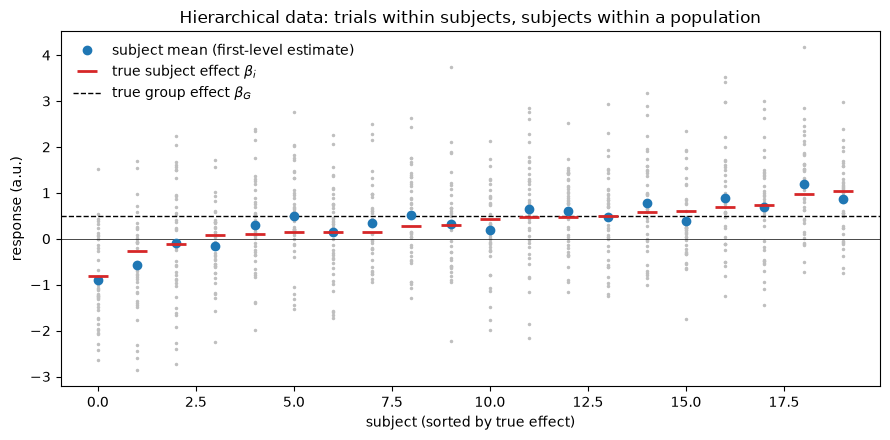

In [2]:
rng = np.random.default_rng(2021)

n_subj, n_trials = 20, 40
beta_G        = 0.5    # true population effect
sigma_between = 0.5    # SD of true subject effects (eta_i)
sigma_within  = 1.0    # SD of trial-level noise (eps_ij)

subj_fx = beta_G + sigma_between * rng.standard_normal(n_subj)     # beta_i
Y = subj_fx + sigma_within * rng.standard_normal((n_trials, n_subj))  # trials x subjects

subj_means = Y.mean(axis=0)   # each subject's first-level (summary) estimate
order = np.argsort(subj_fx)   # sort subjects by true effect, for display

fig, ax = plt.subplots(figsize=(9, 4.5))
for rank, i in enumerate(order):
    ax.plot(np.full(n_trials, rank), Y[:, i], '.', color='0.75', ms=3, zorder=1)
ax.plot(range(n_subj), subj_means[order], 'o', color='tab:blue',
        label='subject mean (first-level estimate)', zorder=3)
ax.plot(range(n_subj), subj_fx[order], '_', color='tab:red', mew=2, ms=14,
        label=r'true subject effect $\beta_i$', zorder=4)
ax.axhline(beta_G, color='k', lw=1, ls='--', label=r'true group effect $\beta_G$')
ax.axhline(0, color='k', lw=0.5)
ax.set(xlabel='subject (sorted by true effect)', ylabel='response (a.u.)',
       title='Hierarchical data: trials within subjects, subjects within a population')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()

Gray dots are individual trials, blue circles are each subject's mean (their first-level summary statistic), and red dashes are the *true* subject effects. Two things to notice:

- Subject means track the true subject effects well — averaging 40 trials beats the trial noise down substantially.
- The subject means spread out far more than trial-averaging noise alone would predict: subjects genuinely differ.

We can check that quantitatively. The variance of the observed subject means should be about $\sigma^2_{between} + \sigma^2_{within}/n_{trials}$ — between-subject variance *plus* the residue of within-subject noise that averaging doesn't remove.

In [3]:
var_means_expected = sigma_between**2 + sigma_within**2 / n_trials
print(f"Variance of subject means, observed:  {subj_means.var(ddof=1):.3f}")
print(f"Expected sigma_b^2 + sigma_w^2/n:     {sigma_between**2:.3f} + "
      f"{sigma_within**2/n_trials:.3f} = {var_means_expected:.3f}")
print(f"\nBetween-subject variance dominates: most of the spread in subject means")
print(f"is real individual difference, not measurement noise.")

Variance of subject means, observed:  0.249
Expected sigma_b^2 + sigma_w^2/n:     0.250 + 0.025 = 0.275

Between-subject variance dominates: most of the spread in subject means
is real individual difference, not measurement noise.


## Step 2 — Fixed effects vs. random effects inference

Now the central question of group analysis: **is the effect nonzero in the population?** Two ways to test it:

- **Fixed effects (FFX, "super subject"):** concatenate all $20 \times 40 = 800$ trials and run one t-test. The error term contains *only* within-subject noise; the between-subject variance $\eta_i$ is nowhere in the model. Degrees of freedom: ~799.
- **Random effects (RFX, summary statistics):** compute each subject's mean, then run a one-sample t-test on the 20 means. Variation *across subjects* is the error term. Degrees of freedom: 19.

Both are t-tests — they differ in what counts as error and in what population the inference covers.

In [4]:
# FFX: pool all trials as one 'super subject'
t_ffx = stats.ttest_1samp(Y.ravel(), 0)
se_ffx = Y.ravel().std(ddof=1) / np.sqrt(Y.size)

# RFX: one-sample t-test on subject means (the summary statistics approach)
t_rfx = stats.ttest_1samp(subj_means, 0)
se_rfx = subj_means.std(ddof=1) / np.sqrt(n_subj)

print(pd.DataFrame({
    "estimate": [Y.mean(), subj_means.mean()],
    "SE":       [se_ffx, se_rfx],
    "t":        [t_ffx.statistic, t_rfx.statistic],
    "df":       [Y.size - 1, n_subj - 1],
    "p":        [t_ffx.pvalue, t_rfx.pvalue],
}, index=["FFX (pool 800 trials)", "RFX (20 subject means)"]).round(4))

                        estimate      SE       t   df       p
FFX (pool 800 trials)      0.356  0.0388  9.1767  799  0.0000
RFX (20 subject means)     0.356  0.1115  3.1927   19  0.0048


Both approaches recover the same group mean (~0.5), but the FFX standard error is far smaller and its t-statistic much larger — it "knows" 800 observations, and its error term ignores the fact that subjects truly differ. That optimism is harmless here, where the effect is real. It becomes a disaster under the null.

### The false-positive experiment

Set the true group effect to **zero** but keep real between-subject variability ($\sigma_{between} = 0.5$): some subjects genuinely activate, others genuinely deactivate, and the population average is nil. A valid test should reject at the nominal rate ($\alpha = 0.05$). We run 2,000 simulated experiments and count rejections — and, as a control, repeat the whole exercise with $\sigma_{between} = 0$ (subjects all identical), the only world where FFX assumptions hold.

In [5]:
def fpr_experiment(sigma_b, n_iter=2000, n_subj=20, n_trials=40, sigma_w=1.0, seed=7):
    """Simulate null-effect experiments; return FFX and RFX false positive rates."""
    rng = np.random.default_rng(seed)
    p_ffx = np.empty(n_iter)
    p_rfx = np.empty(n_iter)
    for it in range(n_iter):
        subj_fx = sigma_b * rng.standard_normal(n_subj)          # true group mean = 0
        Y = subj_fx + sigma_w * rng.standard_normal((n_trials, n_subj))
        p_ffx[it] = stats.ttest_1samp(Y.ravel(), 0).pvalue       # FFX: pool trials
        p_rfx[it] = stats.ttest_1samp(Y.mean(axis=0), 0).pvalue  # RFX: subject means
    return (p_ffx < 0.05).mean(), (p_rfx < 0.05).mean()

results = {}
for sigma_b in [0.0, 0.5]:
    results[sigma_b] = fpr_experiment(sigma_b)

fpr = pd.DataFrame(results, index=["FFX", "RFX"]).T
fpr.index.name = "sigma_between"
print("False positive rate at alpha = .05 (nominal rate: 0.05):\n")
print(fpr.round(3))

False positive rate at alpha = .05 (nominal rate: 0.05):

                 FFX    RFX
sigma_between              
0.0            0.050  0.054
0.5            0.507  0.051


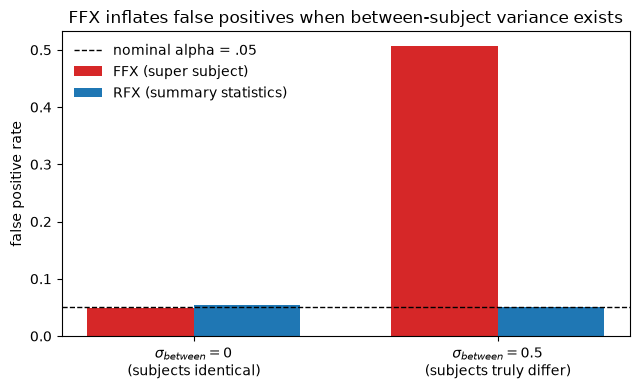

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4))
xpos = np.arange(2)
w = 0.35
ax.bar(xpos - w/2, fpr["FFX"], w, label="FFX (super subject)", color='tab:red')
ax.bar(xpos + w/2, fpr["RFX"], w, label="RFX (summary statistics)", color='tab:blue')
ax.axhline(0.05, color='k', ls='--', lw=1, label='nominal alpha = .05')
ax.set(xticks=xpos,
       xticklabels=[r'$\sigma_{between} = 0$' + '\n(subjects identical)',
                    r'$\sigma_{between} = 0.5$' + '\n(subjects truly differ)'],
       ylabel='false positive rate',
       title='FFX inflates false positives when between-subject variance exists')
ax.legend(frameon=False)
plt.tight_layout()

When subjects are literally identical ($\sigma_{between}=0$), both tests control the error rate. But with realistic between-subject variability, the FFX analysis rejects the true null **most of the time** — a catastrophic false positive rate — while RFX stays at ~5%. This is the core argument for the summary statistics / random effects approach: *the key to valid population inference is treating variation across participants as an error term*. FFX inferences technically apply only to the specific people scanned; RFX inferences generalize to new participants drawn from the same population.

## Step 3 — A genuine mixed effects model

The summary statistics approach implicitly treats subject as a random effect. A **mixed effects model** does it explicitly, in one integrated model of all the trial-level data, estimating both variance components. To make it interesting, we now simulate a *within-subject design*: each subject completes trials in two conditions (A and B, coded ±0.5), and both the intercept and the condition effect (the "slope") vary randomly across subjects:

$$y_{ij} = \beta_{0i} + \beta_{1i}\,cond_{ij} + \epsilon_{ij}, \qquad
(\beta_{0i}, \beta_{1i}) \sim N\big((\beta_{G0}, \beta_{G1}),\, U_G\big)$$

We fit it with `statsmodels` `MixedLM` (random intercept + random slope, REML), and compare against the summary statistics approach: a one-sample t-test on the per-subject condition differences.

In [7]:
rng = np.random.default_rng(33)

n_subj, n_per_cond = 24, 30
betaG_0, betaG_1 = 0.2, 0.6            # population intercept, condition effect
sd_int, sd_slope = 0.4, 0.5            # between-subject SDs of intercept, slope
sigma_w = 1.0

rows = []
for i in range(n_subj):
    b0 = betaG_0 + sd_int * rng.standard_normal()
    b1 = betaG_1 + sd_slope * rng.standard_normal()
    cond = np.repeat([-0.5, 0.5], n_per_cond)      # B, A (effects coded)
    y = b0 + b1 * cond + sigma_w * rng.standard_normal(cond.size)
    rows.append(pd.DataFrame({"subject": i, "cond": cond, "y": y}))
df = pd.concat(rows, ignore_index=True)

print(df.head())
print(f"\n{df.shape[0]} trials: {n_subj} subjects x {2*n_per_cond} trials")

   subject  cond         y
0        0  -0.5  0.788889
1        0  -0.5  0.242172
2        0  -0.5 -1.370847
3        0  -0.5  1.201709
4        0  -0.5  0.102178

1440 trials: 24 subjects x 60 trials


In [8]:
# Mixed effects model: fixed effect of condition, random intercept + slope per subject
mlm = smf.mixedlm("y ~ cond", df, groups=df["subject"], re_formula="~cond")
mfit = mlm.fit(reml=True, method="lbfgs")
print(mfit.summary())

          Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: y         
No. Observations:   1440    Method:             REML      
No. Groups:         24      Scale:              0.9751    
Min. group size:    60      Log-Likelihood:     -2074.2000
Max. group size:    60      Converged:          Yes       
Mean group size:    60.0                                  
----------------------------------------------------------
                 Coef.  Std.Err.   z   P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept         0.237    0.091 2.597 0.009  0.058  0.415
cond              0.539    0.127 4.241 0.000  0.290  0.788
Group Var         0.183    0.060                          
Group x cond Cov -0.152    0.067                          
cond Var          0.323    0.117                          



In [9]:
# Summary statistics approach: per-subject condition difference, then one-sample t-test
diffs = (df[df.cond > 0].groupby("subject").y.mean()
         - df[df.cond < 0].groupby("subject").y.mean())
t_ss = stats.ttest_1samp(diffs, 0)
se_ss = diffs.std(ddof=1) / np.sqrt(n_subj)

comparison = pd.DataFrame({
    "estimate": [mfit.params["cond"], diffs.mean()],
    "SE":       [mfit.bse["cond"], se_ss],
    "p":        [mfit.pvalues["cond"], t_ss.pvalue],
}, index=["Mixed model (fixed effect of cond)", "Summary statistics (t-test on diffs)"])
print(comparison.round(4))

sd_slope_hat = np.sqrt(mfit.cov_re.loc["cond", "cond"])
print(f"\nEstimated between-subject SD of the condition effect: {sd_slope_hat:.3f}"
      f"  (true: {sd_slope})")
print(f"Estimated residual (within-subject) SD: {np.sqrt(mfit.scale):.3f}  (true: {sigma_w})")

                                      estimate      SE       p
Mixed model (fixed effect of cond)       0.539  0.1271  0.0000
Summary statistics (t-test on diffs)     0.539  0.1271  0.0003

Estimated between-subject SD of the condition effect: 0.568  (true: 0.5)
Estimated residual (within-subject) SD: 0.987  (true: 1.0)


The two approaches agree almost perfectly on the condition effect, its standard error, and the p-value — as theory predicts. With a **balanced design and homogeneous within-subject error**, the two-stage summary statistics approach is fully efficient: it *is* a mixed effects analysis in disguise. The mixed model earns its keep by also delivering explicit estimates of the variance components (compare the estimated between-subject slope SD and residual SD with the true values), and it generalizes better when data are missing, unbalanced, or of variable quality across subjects — that is where precision weighting (as in FSL's FLAME, AFNI's 3dMEMA, or CANlab's `glmfit_multilevel` / `igls`) starts to matter.

## Step 4 — Robust vs. OLS group estimates with an outlier subject

At the second level, each subject contributes a single contrast (COPE) value per voxel. With thousands of voxels no one can inspect them all, and a single artifactual subject can wreck a voxel's group statistics. We recreate the book's demonstration: **no true relationship** between a covariate (say, behavioral performance) and the contrast — until one outlier subject creates one.

Robust regression by **iteratively reweighted least squares (IRLS)** refits the model repeatedly, each time down-weighting points that sit far from the current fit, so the final estimate reflects the central mass of subjects.

In [10]:
rng = np.random.default_rng(11)
n_subj = 30

perf = rng.standard_normal(n_subj)         # mean-centered covariate
cope = 0.3 * rng.standard_normal(n_subj)   # contrast values: true slope = 0
perf_o, cope_o = perf.copy(), cope.copy()
perf_o[-1], cope_o[-1] = 4.0, 3.0          # one extreme outlier subject

X_clean = sm.add_constant(perf)
X_out   = sm.add_constant(perf_o)

ols_clean = sm.OLS(cope, X_clean).fit()
ols_out   = sm.OLS(cope_o, X_out).fit()
rob_out   = sm.RLM(cope_o, X_out, M=sm.robust.norms.TukeyBiweight()).fit()

print(pd.DataFrame({
    "slope":  [ols_clean.params[1], ols_out.params[1], rob_out.params[1]],
    "SE":     [ols_clean.bse[1], ols_out.bse[1], rob_out.bse[1]],
    "p":      [ols_clean.pvalues[1], ols_out.pvalues[1], rob_out.pvalues[1]],
}, index=["OLS, clean data", "OLS, with outlier", "Robust IRLS, with outlier"]).round(4))
print(f"\nIRLS weight given to the outlier subject: {rob_out.weights[-1]:.3f}")

                            slope      SE       p
OLS, clean data           -0.0251  0.0542  0.6468
OLS, with outlier          0.2807  0.0808  0.0017
Robust IRLS, with outlier -0.0360  0.0457  0.4304

IRLS weight given to the outlier subject: 0.000


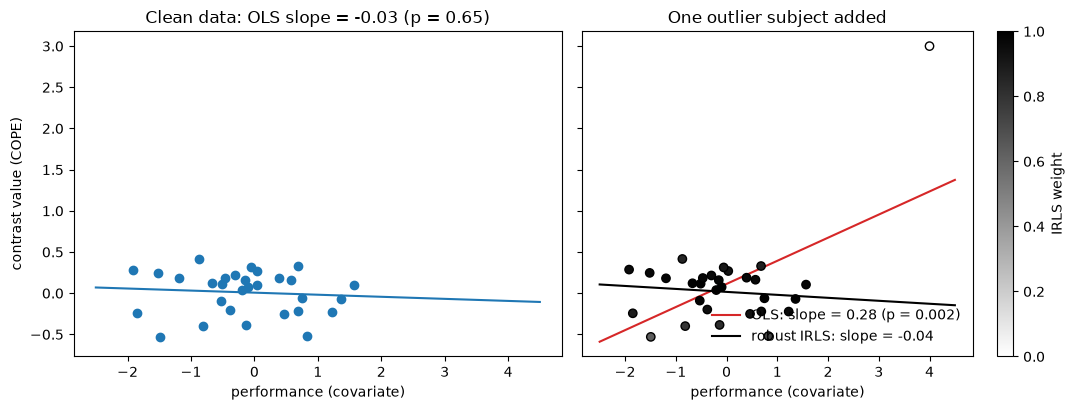

In [11]:
xg = np.linspace(-2.5, 4.5, 50)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

axes[0].plot(perf, cope, 'o', color='tab:blue')
axes[0].plot(xg, ols_clean.params[0] + ols_clean.params[1] * xg, '-', color='tab:blue')
axes[0].set(title=f'Clean data: OLS slope = {ols_clean.params[1]:.2f} '
                  f'(p = {ols_clean.pvalues[1]:.2f})',
            xlabel='performance (covariate)', ylabel='contrast value (COPE)')

# color points by their IRLS weight: light = down-weighted
sc = axes[1].scatter(perf_o, cope_o, c=rob_out.weights, cmap='gray_r',
                     vmin=0, vmax=1, edgecolor='k', zorder=3)
axes[1].plot(xg, ols_out.params[0] + ols_out.params[1] * xg, '-', color='tab:red',
             label=f'OLS: slope = {ols_out.params[1]:.2f} (p = {ols_out.pvalues[1]:.3f})')
axes[1].plot(xg, rob_out.params[0] + rob_out.params[1] * xg, '-', color='k',
             label=f'robust IRLS: slope = {rob_out.params[1]:.2f}')
axes[1].set(title='One outlier subject added', xlabel='performance (covariate)')
axes[1].legend(frameon=False, loc='lower right')
fig.colorbar(sc, ax=axes[1], label='IRLS weight')
plt.tight_layout()

The single outlier subject drags the OLS slope from ~0 to strongly positive and makes it "significant" — a spurious brain–behavior correlation. The robust fit assigns the outlier a weight near zero (lighter shading = down-weighted) and recovers the null slope of the other 29 subjects. The same logic protects the humble group mean: an extreme subject can also mask a *true* group activation, which robust estimation recovers.

The cost–benefit is favorable: with no true outliers, IRLS loses only a little power relative to OLS; with outliers, it prevents both spurious findings and masked true effects, and improves power in real group fMRI analyses. In CANlab tools, `robfit.m` applies exactly this voxelwise to contrast images (producing robust group t-maps); most robust group analyses run on first-level summary statistics, since mixed models with robust reweighting are not generally available.

## Wrap-up

- Multi-subject data are hierarchical; valid population inference requires **between-subject variability in the error term**.
- **FFX** ("super subject") analyses omit that variance component: fine only if subjects are identical, badly anticonservative otherwise.
- The **summary statistics** approach (one number per subject, then a group GLM) implicitly treats subject as a random effect, and is fully efficient when first-level precision is homogeneous — which is why ~90% of fMRI studies use it.
- **Mixed models** estimate the variance components explicitly and win with unbalanced, missing, or variable-quality data.
- **Robust IRLS** regression is cheap insurance against outlier subjects at the second level.

Next, Chapter 22 confronts what happens when you run this group test at 100,000 voxels at once: the multiple comparisons problem.